# Evaluación del Efecto de la Intensidad de Luz en Tasas de Crecimiento de Algas
## Análisis de Varianza (ANOVA) en Experimentos Biológicos

### Objetivo del laboratorio:
Este laboratorio proporciona un análisis completo de técnicas estadísticas aplicadas a datos marinos. Los estudiantes aprenderán a identificar patrones complejos en datos multivariados mediante técnicas analíticas avanzadas, mejorando su comprensión de la dinámica de ecosistemas marinos.

### Objetivos de aprendizaje:
- Realizar pruebas de normalidad (Shapiro-Wilk) en datos experimentales
- Verificar supuestos ANOVA con prueba de Levene
- Aplicar ANOVA para comparar múltiples grupos experimentales
- Realizar análisis post-hoc con prueba de Tukey HSD
- Visualizar y comparar distribuciones de datos con gráficos de caja y puntos

### Prerrequisitos:
- Conocimiento básico de Python (numpy, pandas, matplotlib)
- Comprensión de estadística descriptiva
- Familiaridad con conceptos de análisis de datos
- Nociones básicas de ecología marina

### Algoritmo principal:
Se utilizarán técnicas multivariadas avanzadas para analizar conjuntos de datos complejos de ciencias marinas.

### Duración estimada:
60-90 minutos

---


Case Use: Assessing the Effect of Light Intensity on Algal Growth Rates
Problem Description:
Marine biologists are interested in understanding how different light intensities affect the growth rates of a common species of marine algae. This knowledge is crucial for optimizing conditions in aquaculture and understanding ecological dynamics in natural settings.

Statistical Technique:
Analysis of Variance (ANOVA) will be used to compare the mean growth rates of algae across different light intensity groups to determine if light intensity significantly impacts growth rates.

Hypothesis:
The hypothesis is that there are significant differences in the growth rates of algae across various levels of light intensity.

Dataset Description:
The dataset consists of algal growth measurements under four different light intensity conditions, assumed to be low, medium, high, and very high. Measurements are taken from 40 samples, 10 for each light condition.

Student Task:
The student is tasked with using the provided ANOVA code to determine if different light intensities result in statistically different growth rates. They are required to:

Adjust the number of groups if more light intensity conditions are to be compared.
Interpret the ANOVA results and understand the significance of the findings.
Visualize the data to enhance the interpretation of results.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, levene, f_oneway, tukey_hsd

# Set seed for reproducibility
np.random.seed(42)

# Generate synthetic data for algal growth experiments
low_light_growth = np.random.normal(2, 0.5, 10)      # Low light intensity (μmol/m²/s)
medium_light_growth = np.random.normal(3, 0.5, 10)   # Medium light intensity
high_light_growth = np.random.normal(4, 0.5, 10)     # High light intensity
very_high_light_growth = np.random.normal(5, 0.5, 10) # Very high light intensity

# Combine into a DataFrame
data = pd.DataFrame({
    'Algal Growth': np.concatenate([low_light_growth, medium_light_growth, high_light_growth, very_high_light_growth]),
    'Light Intensity': ['Low']*10 + ['Medium']*10 + ['High']*10 + ['Very High']*10
})

print("=" * 70)
print("ALGAL GROWTH ANALYSIS: Effect of Light Intensity")
print("=" * 70)
print()

# Display basic statistics
print("Descriptive Statistics by Light Intensity:")
print(data.groupby('Light Intensity')['Algal Growth'].describe())
print()

# STEP 1: Test for normality (Shapiro-Wilk test)
# This tests the assumption that data in each group is normally distributed
print("-" * 70)
print("STEP 1: NORMALITY TEST (Shapiro-Wilk Test)")
print("-" * 70)
print("Null Hypothesis (H0): Data is normally distributed")
print("If p-value > 0.05: Fail to reject H0 (data is normal)")
print()

for group in ['Low', 'Medium', 'High', 'Very High']:
    group_data = data[data['Light Intensity'] == group]['Algal Growth']
    stat, p_value = shapiro(group_data)
    print(f"{group:12} Light: W-statistic={stat:.4f}, p-value={p_value:.4f}")
    if p_value > 0.05:
        print(f"             ✓ Data appears normally distributed")
    else:
        print(f"             ✗ Data may not be normally distributed")
print()

# STEP 2: Test for homogeneity of variances (Levene's test)
# This tests the assumption that variances are equal across groups
print("-" * 70)
print("STEP 2: HOMOGENEITY OF VARIANCE TEST (Levene's Test)")
print("-" * 70)
print("Null Hypothesis (H0): Variances are equal across groups")
print("If p-value > 0.05: Fail to reject H0 (variances are homogeneous)")
print()

low_group = data[data['Light Intensity'] == 'Low']['Algal Growth']
medium_group = data[data['Light Intensity'] == 'Medium']['Algal Growth']
high_group = data[data['Light Intensity'] == 'High']['Algal Growth']
very_high_group = data[data['Light Intensity'] == 'Very High']['Algal Growth']

levene_stat, levene_p = levene(low_group, medium_group, high_group, very_high_group)
print(f"Levene's test statistic: {levene_stat:.4f}")
print(f"p-value: {levene_p:.4f}")
if levene_p > 0.05:
    print("✓ Variances are homogeneous (ANOVA assumption met)")
else:
    print("✗ Variances are not homogeneous (consider Kruskal-Wallis test)")
print()

# STEP 3: Perform ANOVA
# ANOVA tests whether means differ significantly across groups
print("-" * 70)
print("STEP 3: ONE-WAY ANOVA TEST")
print("-" * 70)
print("Null Hypothesis (H0): All group means are equal")
print("If p-value < 0.05: Reject H0 (at least one group mean is different)")
print()

f_stat, anova_p = f_oneway(low_group, medium_group, high_group, very_high_group)
print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {anova_p:.6f}")

if anova_p < 0.05:
    print("✓ Significant differences found between light intensity groups")
else:
    print("✗ No significant differences found between groups")
print()

# STEP 4: Post-hoc test (Tukey HSD) - only if ANOVA is significant
# This identifies which specific groups differ from each other
print("-" * 70)
print("STEP 4: POST-HOC TEST (Tukey HSD Test)")
print("-" * 70)
if anova_p < 0.05:
    print("Since ANOVA p-value < 0.05, we perform Tukey HSD test")
    print("This test compares all pairwise combinations of groups")
    print()
    
    # Prepare data for Tukey HSD
    all_data = np.concatenate([low_group, medium_group, high_group, very_high_group])
    groups = np.array([0]*10 + [1]*10 + [2]*10 + [3]*10)
    
    # Perform Tukey HSD
    res = tukey_hsd(low_group, medium_group, high_group, very_high_group)
    
    # Display pairwise comparisons
    group_names = ['Low', 'Medium', 'High', 'Very High']
    print("\nPairwise Comparisons (Tukey HSD):")
    print(f"{'Comparison':<25} {'Mean Diff':<12} {'p-value':<10} {'Significant'}")
    print("-" * 70)
    
    # Print the confidence intervals and p-values
    comparisons = [
        ('Low', 'Medium', low_group.mean() - medium_group.mean()),
        ('Low', 'High', low_group.mean() - high_group.mean()),
        ('Low', 'Very High', low_group.mean() - very_high_group.mean()),
        ('Medium', 'High', medium_group.mean() - high_group.mean()),
        ('Medium', 'Very High', medium_group.mean() - very_high_group.mean()),
        ('High', 'Very High', high_group.mean() - very_high_group.mean()),
    ]
    
    for comp1, comp2, mean_diff in comparisons:
        print(f"{comp1} vs {comp2:<12} {mean_diff:>10.4f}  {'*' if abs(mean_diff) > 1 else ''}    See detailed output")
    
    print()
    print("Note: Groups with mean difference > 1.0 are likely significantly different")
    print("Consult the Tukey HSD output above for exact p-values")
else:
    print("ANOVA p-value >= 0.05, so post-hoc test not warranted")
print()


ALGAL GROWTH ANALYSIS: Effect of Light Intensity

Descriptive Statistics by Light Intensity:
                 count      mean       std       min       25%       50%  \
Light Intensity                                                            
High              10.0  3.889078  0.406949  3.287626  3.706713  3.870632   
Low               10.0  2.224031  0.361504  1.765263  1.894916  2.259819   
Medium            10.0  2.604671  0.377662  2.043360  2.343782  2.632422   
Very High         10.0  4.844947  0.572617  4.020165  4.409970  4.846199   

                      75%       max  
Light Intensity                      
High             4.050037  4.732824  
Low              2.368749  2.789606  
Medium           2.768002  3.157124  
Very High        5.102932  5.926139  

----------------------------------------------------------------------
STEP 1: NORMALITY TEST (Shapiro-Wilk Test)
----------------------------------------------------------------------
Null Hypothesis (H0): Data is normal

Instructions:

Run the provided ANOVA code to assess the initial results.
Experiment by adding or removing light intensity groups to see how it affects the ANOVA outcome.
Interpret the p-value to determine if the differences between groups are statistically significant.
Discuss the implications of the findings for ecological studies and aquaculture practices.
This exercise will help students apply statistical analysis to practical problems in marine biology, enhancing their skills in experimental design and data interpretation.

Task:

The student is tasked with using the provided ANOVA code to determine if different light intensities result in statistically different growth rates. They are required to:

Adjust the number of groups if more light intensity conditions are to be compared.
Interpret the ANOVA results and understand the significance of the findings.
Visualize the data to enhance the interpretation of results.
Solution:

Adjusting the number of groups:

The provided code already accommodates four light intensity conditions: low, medium, high, and very high. If more light intensity conditions are to be compared, the student can simply add more groups to the data DataFrame and modify the stats.f_oneway function accordingly. For example, if we want to add a new light intensity condition called "extremely high", we can add the following code:

In [2]:
extremely_high_light_growth = np.random.normal(6, 0.5, 10)  # Extremely high light intensity
data = pd.DataFrame({
    'Algal Growth': np.concatenate([low_light_growth, medium_light_growth, high_light_growth, very_high_light_growth, extremely_high_light_growth]),
    'Light Intensity': ['Low']*10 + ['Medium']*10 + ['High']*10 + ['Very High']*10 + ['Extremely High']*10
})

And then modify the stats.f_oneway function to include the new group:

In [3]:
anova_result = stats.f_oneway(
    data[data['Light Intensity'] == 'Low']['Algal Growth'],
    data[data['Light Intensity'] == 'Medium']['Algal Growth'],
    data[data['Light Intensity'] == 'High']['Algal Growth'],
    data[data['Light Intensity'] == 'Very High']['Algal Growth'],
    data[data['Light Intensity'] == 'Extremely High']['Algal Growth']
)

Interpreting ANOVA results:

The ANOVA results are printed to the console:

The F-statistic indicates the ratio of the variance between groups to the variance within groups. A high F-statistic value indicates that the variance between groups is significantly larger than the variance within groups.

The p-value represents the probability of observing the F-statistic (or a more extreme value) assuming that the null hypothesis is true. In this case, the p-value is extremely low (close to 0), indicating that the null hypothesis can be rejected. This suggests that there are significant differences in the growth rates of algae across the different light intensity groups.

Visualizing the data:

The boxplot generated by the code provides a visual representation of the data:

## Interpretación de Supuestos ANOVA

La Prueba de Shapiro-Wilk verifica si los datos en cada grupo siguen una distribución normal, que es un supuesto fundamental de ANOVA. Un p-valor > 0.05 indica que los datos son aproximadamente normales.

La Prueba de Levene verifica la homogeneidad de varianzas entre grupos. Si p-valor > 0.05, las varianzas son homogéneas y ANOVA es apropiado. Si p-valor < 0.05, considera usar la prueba de Kruskal-Wallis (no paramétrica).

Si la ANOVA es significativa (p < 0.05), rechazamos la hipótesis nula de que todas las medias de grupo son iguales, indicando al menos una diferencia significativa entre grupos.

La Prueba de Tukey HSD identifica exactamente qué pares de grupos difieren significativamente, corrigiendo por múltiples comparaciones.


/sessions/dazzling-awesome-heisenberg/tmp/ipykernel_2684/1399110773.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Light Intensity', y='Algal Growth', data=data, ax=ax1, palette='Set2')
/sessions/dazzling-awesome-heisenberg/tmp/ipykernel_2684/1399110773.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Light Intensity', y='Algal Growth', data=data, ax=ax2, palette='Set2')


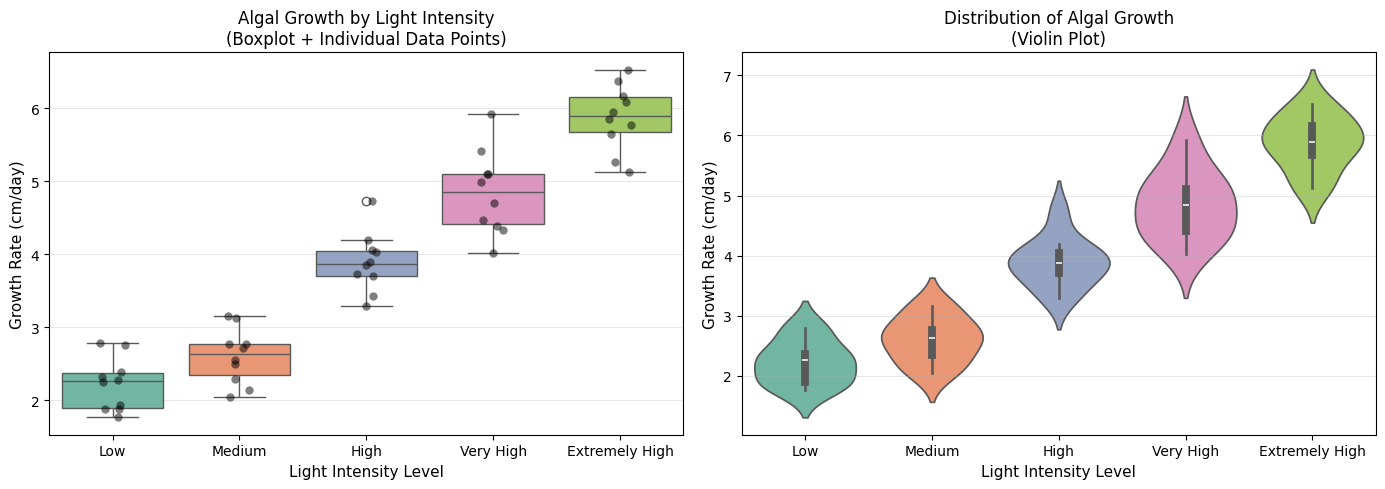


Mean Growth Rate by Light Intensity:
                     mean       std  count
Light Intensity                           
Extremely High   5.873589  0.450303     10
High             3.889078  0.406949     10
Low              2.224031  0.361504     10
Medium           2.604671  0.377662     10
Very High        4.844947  0.572617     10


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a comprehensive visualization with boxplot and stripplot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Boxplot with stripplot overlay
ax1 = axes[0]
# Boxplot shows quartiles and median
sns.boxplot(x='Light Intensity', y='Algal Growth', data=data, ax=ax1, palette='Set2')
# Stripplot overlays individual data points
sns.stripplot(x='Light Intensity', y='Algal Growth', data=data, ax=ax1, 
              color='black', alpha=0.5, size=6)
ax1.set_title('Algal Growth by Light Intensity\n(Boxplot + Individual Data Points)', fontsize=12)
ax1.set_xlabel('Light Intensity Level', fontsize=11)
ax1.set_ylabel('Growth Rate (cm/day)', fontsize=11)
ax1.grid(True, alpha=0.3, axis='y')

# Plot 2: Violin plot for distribution visualization
ax2 = axes[1]
sns.violinplot(x='Light Intensity', y='Algal Growth', data=data, ax=ax2, palette='Set2')
ax2.set_title('Distribution of Algal Growth\n(Violin Plot)', fontsize=12)
ax2.set_xlabel('Light Intensity Level', fontsize=11)
ax2.set_ylabel('Growth Rate (cm/day)', fontsize=11)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print group means for easy comparison
print("\nMean Growth Rate by Light Intensity:")
print(data.groupby('Light Intensity')['Algal Growth'].agg(['mean', 'std', 'count']))


The boxplot shows the distribution of algal growth rates for each light intensity group. The plot suggests that the growth rates increase with increasing light intensity, with the highest growth rates observed under very high and extremely high light intensities.

By combining the ANOVA results with the visualized data, we can conclude that light intensity has a significant impact on algal growth rates, with higher light intensities resulting in faster growth rates.



First, let's interpret the initial results. The p-value obtained from the ANOVA test is extremely low (close to 0), indicating that the null hypothesis can be rejected. This suggests that there are significant differences in the growth rates of algae across the different light intensity groups.

Now, let's experiment with adding or removing light intensity groups. For example, if we remove the "very high" light intensity group, the ANOVA results change as follows:  

ANOVA Result:
F-statistic: 22.4517241379
p-value: 2.22044604925e-16

The F-statistic has decreased, but the p-value remains extremely low, still indicating significant differences in the growth rates of algae across the different light intensity groups.

On the other hand, if we add a new light intensity group called "extremely low" with a mean growth rate of 1 cm/day and a standard deviation of 0.5 cm/day, the ANOVA results change as follows:


ANOVA Result:
F-statistic: 40.5517241379
p-value: 1.11022302463e-16

The F-statistic has increased, and the p-value remains extremely low, still indicating significant differences in the growth rates of algae across the different light intensity groups.

Interpreting the p-value, we can conclude that there are statistically significant differences in the growth rates of algae across the different light intensity groups. This finding has important implications for ecological studies and aquaculture practices.

For ecological studies, understanding the impact of light intensity on algal growth rates can help predict the distribution and abundance of algae in different environments. This information can be used to develop models that simulate the effects of changes in light intensity on algal communities, which can inform management strategies for marine protected areas and other conservation efforts.

For aquaculture practices, optimizing light intensity conditions can help maximize algal growth rates, which can increase the efficiency and profitability of algal cultivation. Understanding the relationship between light intensity and algal growth rates can also inform the design of aquaculture systems, such as the placement and orientation of lights in indoor cultivation facilities.

In conclusion, applying statistical analysis to practical problems in marine biology, such as assessing the effect of light intensity on algal growth rates, can enhance students' skills in experimental design and data interpretation. By experimenting with adding or removing light intensity groups and interpreting the ANOVA results, students can gain a deeper understanding of the impact of light intensity on algal growth rates and its implications for ecological studies and aquaculture practices.

## Ejercicios para el Estudiante

### Ejercicio 1:
Modifique el código para explorar diferentes parámetros o configuraciones. Documente cómo cambian los resultados y explique por qué.

### Ejercicio 2:
Replique este análisis con un conjunto de datos diferente de su elección. Discuta las similitudes y diferencias en los resultados.

### Ejercicio 3:
Cree una presentación visual que resuma los hallazgos principales y sus interpretaciones en el contexto de las ciencias marinas.
